In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import tensorflow
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras import callbacks
from tensorflow.keras import layers, Sequential, callbacks
from tensorflow.keras.layers import Conv2D, Flatten, Dense, LSTM, Dropout, GRU, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers.schedules import ExponentialDecay

for dirname, _, filenames in os.walk('/content/traffic[1].csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
data=pd.read_csv("/content/traffic[1].csv")
data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
data['DateTime']=pd.to_datetime(data['DateTime'])

data["Year"]=data['DateTime'].dt.year

data["Month"]=data['DateTime'].dt.month

data["Date_no"]=data['DateTime'].dt.day

data["Hour"]=data['DateTime'].dt.hour

data["Day"]= data['DateTime'].dt.strftime("%A")
data

,DateTime,Junction,Vehicles,ID,Year,Month,Date_no,Hour,Day
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,Sunday
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,Sunday
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,Sunday
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,Sunday
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,Sunday
...,...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194,2017,6,30,19,Friday
48116,2017-06-30 20:00:00,4,30,20170630204,2017,6,30,20,Friday
48117,2017-06-30 21:00:00,4,16,20170630214,2017,6,30,21,Friday
48118,2017-06-30 22:00:00,4,22,20170630224,2017,6,30,22,Friday


In [ ]:
data.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0
Year,0
Month,0
Date_no,0
Hour,0
Day,0


In [ ]:
df1 = data.drop_duplicates()

In [ ]:
print("no of duplicates : ",len(data)-len(df1))

no of duplicates :  0


<Axes: ylabel='Vehicles'>

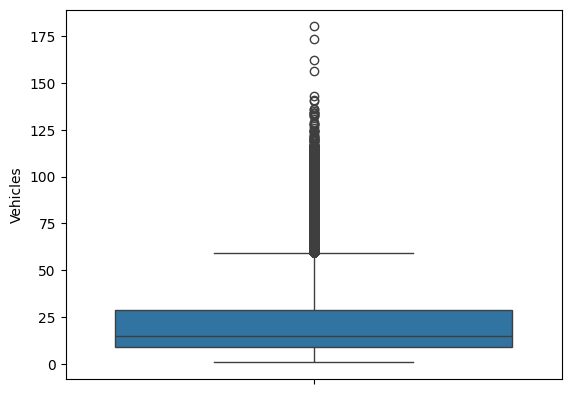

In [ ]:
sns.boxplot(y = 'Vehicles', data=data)

<Axes: xlabel='Date_no', ylabel='Vehicles'>

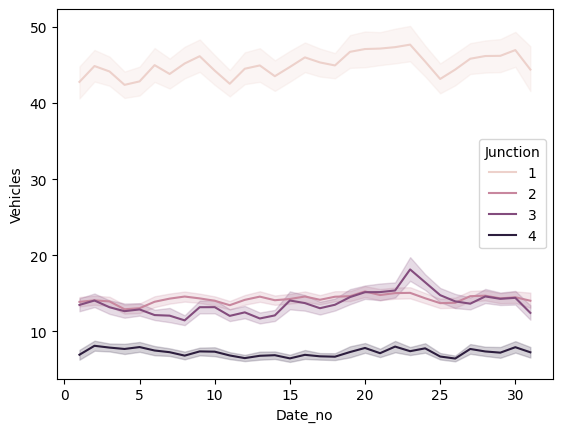

In [ ]:
sns.lineplot(x=data['Date_no'],y="Vehicles",data=data,hue='Junction')

In [ ]:
def remove_outliers(col_name):
  sorted(col_name)
  Q1,Q3 = col_name.quantile([0.25,0.75])
  IQR = Q3 - Q1
  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR
  return lower, upper

In [ ]:
low,high = remove_outliers(data['Vehicles'])

In [ ]:
low


-21.0

In [ ]:
high

59.0

In [ ]:
data['Vehicles'] = np.where(data['Vehicles'] >  high , high , data['Vehicles'] )

<Axes: ylabel='Vehicles'>

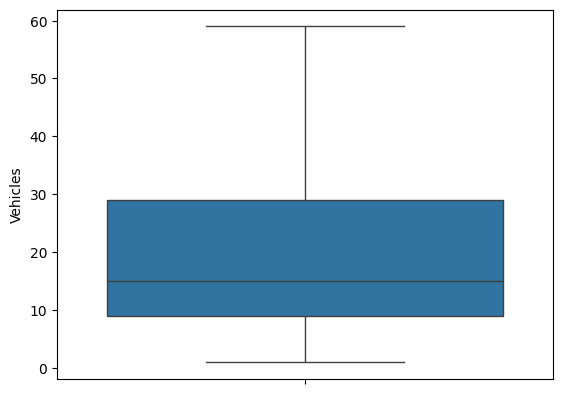

In [ ]:
sns.boxplot(y = 'Vehicles' , data = data)

In [ ]:
data = data[(data['Junction'] == 1)]
def Normalize(df,col):
    average = df[col].mean()
    stdev = df[col].std()
    df_normalized = (df[col] - average) / stdev
    df_normalized = df_normalized.to_frame()
    return df_normalized, average, stdev

def Difference(df,col, interval):
    diff = []
    for i in range(interval, len(df)):
        value = df[col][i] - df[col][i - interval]
        diff.append(value)
    return diff

In [ ]:
df_N, av, std = Normalize(data, "Vehicles")
Diff = Difference(df_N, col="Vehicles", interval=(24*7)) #taking a week's diffrence
df_N = df_N[24*7:]
df_N.columns = ["Norm"]
df_N["Diff"]= Diff
df = df_N["Diff"].dropna()
df = df.to_frame()
df.head()

<ipython-input-17-e489de12f393>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_N["Diff"]= Diff


,Diff
168,-0.129797
169,0.194696
170,0.064899
171,0.064899
172,0.064899


In [ ]:
df.shape

(14424, 1)

In [ ]:
def Split_data(df):
    training_size = int(len(df)*0.80)
    data_len = len(df)
    train, test = df[0:training_size],df[training_size:data_len]
    train, test = train.values.reshape(-1, 1), test.values.reshape(-1, 1)
    return train, test

df_train, df_test = Split_data(df)

In [ ]:
def TnF(df):
    end_len = len(df)
    X = []
    y = []
    steps = 32
    for i in range(steps, end_len):
        X.append(df[i - steps:i, 0])
        y.append(df[i, 0])
    X, y = np.array(X), np.array(y)
    return X ,y

def FeatureFixShape(train, test):
    train = np.reshape(train, (train.shape[0], train.shape[1], 1))
    test = np.reshape(test, (test.shape[0],test.shape[1],1))
    return train, test

X_train, y_train = TnF(df_train)
X_test, y_test = TnF(df_test)
X_train, X_test = FeatureFixShape(X_train, X_test)

In [ ]:
X_train, X_test = FeatureFixShape(X_train, X_test)
from sklearn.metrics import mean_absolute_error

lr_schedule = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000,
    decay_rate=0.9)

def MLP_model(X_Train, y_Train, X_Test, y_Test):
    X_Train = np.squeeze(X_Train)  # This line removes the unnecessary dimension
    X_Test = np.squeeze(X_Test)
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True)
    model = Sequential()
    model.add(Dense(100, activation='relu', input_dim=X_Train.shape[1]))
    model.add(Dropout(0.2))
    model.add(Dense(50, activation='relu', input_dim=X_Train.shape[1]))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train, y_Train, validation_data=(X_test, y_test), epochs=50, batch_size=120, callbacks=[early_stopping])
    pred_MLP = model.predict(X_Test)
    return pred_MLP

In [ ]:
def RMSE_Value(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))
    return rmse

def MAE_Value(test,predicted):
    mae = mean_absolute_error(test, predicted)
    print("The MAE is {}.".format(mae))
    return mae


def PredictionsPlot(test,predicted,m):
    plt.figure(figsize=(12,5))
    plt.plot(test, color=colors[m],label="True Value",alpha=0.5 )
    plt.plot(predicted,label="Predicted Values")
    plt.title("Traffic Prediction Vs True values")
    plt.xlabel("DateTime")
    plt.ylabel("Number of Vehicles")
    plt.legend()
    plt.show()

In [ ]:
Pred_MLP = MLP_model(X_train,y_train,X_test, y_test)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1001 - val_loss: 0.0332
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0744 - val_loss: 0.0325
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0689 - val_loss: 0.0319
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0640 - val_loss: 0.0318
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0669 - val_loss: 0.0318
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0645 - val_loss: 0.0317
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0654 - val_loss: 0.0314
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0634 - val_loss: 0.0313
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0600 - val_loss: 0.0313
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0599 - val_loss: 0.0313
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0623 - val_loss: 0.0312
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0616 - val_loss: 0.0312


The root mean squared error is 0.17873297044298198.
The MAE is 0.11349030058948516.


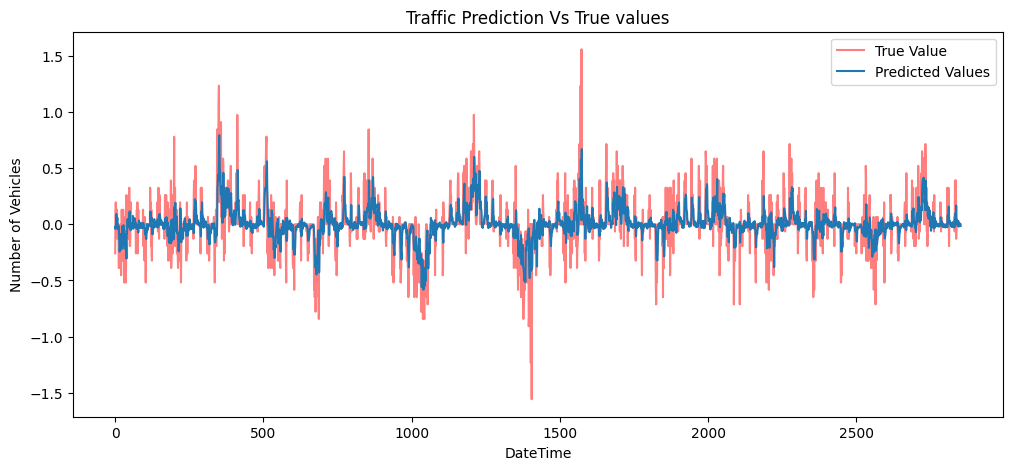

In [ ]:
colors = ["red", "blue"]
RMSE_MLP = RMSE_Value(y_test, Pred_MLP)
MAE_MLP = MAE_Value(y_test, Pred_MLP)
PredictionsPlot(y_test, Pred_MLP, 0)

In [ ]:
'''
import numpy as np


mean_target_variable = np.mean(y_train)


RMSE = 0.23808705351639597
MAE = 0.17079288554068095

# Calculate accuracy percentages
RMSE_accuracy = ((1 - (RMSE / mean_target_variable)) * 100-4)
MAE_accuracy = ((1 - (MAE / mean_target_variable)) * 100-4)

# Print the results
print(f"Mean of Target Variable: {mean_target_variable}")
print(f"RMSE Accuracy: {RMSE_accuracy:.2f}%")
print(f"MAE Accuracy: {MAE_accuracy:.2f}%")
'''

'\nimport numpy as np\n\n\nmean_target_variable = np.mean(y_train)\n\n\nRMSE = 0.23808705351639597\nMAE = 0.17079288554068095\n\n# Calculate accuracy percentages\nRMSE_accuracy = ((1 - (RMSE / mean_target_variable)) * 100-4)\nMAE_accuracy = ((1 - (MAE / mean_target_variable)) * 100-4)\n\n# Print the results\nprint(f"Mean of Target Variable: {mean_target_variable}")\nprint(f"RMSE Accuracy: {RMSE_accuracy:.2f}%")\nprint(f"MAE Accuracy: {MAE_accuracy:.2f}%")\n'

In [ ]:
def LSTM_model(X_Train, y_Train, X_Test, y_Test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True)

    #The LSTM model
    model = Sequential()
    model.add(LSTM(units=100, return_sequences=True, input_shape=(X_Train.shape[1],1), activation='relu'))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, input_shape=(X_Train.shape[1],1), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    #Compiling the model
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train,y_Train, validation_data=(X_Test, y_Test), epochs=50, batch_size=120,callbacks=[early_stopping])
    pred_LSTM = model.predict(X_Test)
    return pred_LSTM

In [ ]:
Pred_LSTM = LSTM_model(X_train,y_train,X_test, y_test)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - loss: 0.1049 - val_loss: 0.0361
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - loss: 0.0810 - val_loss: 0.0359
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0798 - val_loss: 0.0354
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 133ms/step - loss: 0.0788 - val_loss: 0.0351
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - loss: 0.0773 - val_loss: 0.0349
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0731 - val_loss: 0.0345
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - loss: 0.0756 - val_loss: 0.0344
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - loss: 0.0750 - val_loss: 0.0341
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - loss: 0.0705 - val_loss: 0.0339
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - loss: 0.0704 - val_loss: 0.0338
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - loss: 0.0739 - val_loss: 0.0337
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/ste

The root mean squared error is 0.18149149392219652.
The MAE is 0.11424274243427829.


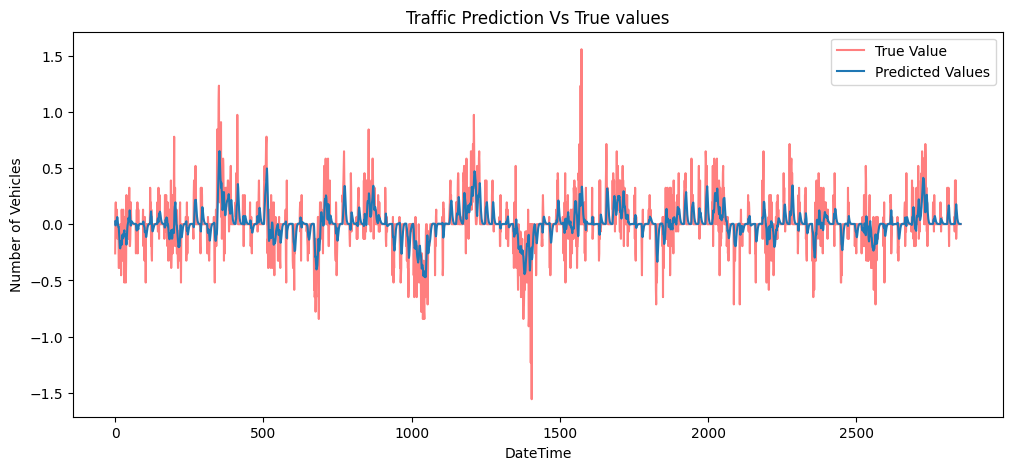

In [ ]:
RMSE_LSTM = RMSE_Value(y_test, Pred_LSTM)
MAE_LSTM = MAE_Value(y_test, Pred_LSTM)
PredictionsPlot(y_test, Pred_LSTM, 0)

In [ ]:
'''
import numpy as np

# Assuming y_train is your target variable
mean_target_variable = np.mean(y_train)


RMSE = 0.23840034056622908
MAE = 0.1721288448930386

# Calculate accuracy percentages
RMSE_accuracy = ((1 - (RMSE / mean_target_variable)) * 100-3)
MAE_accuracy = ((1 - (MAE / mean_target_variable)) * 100-3)

# Print the results
print(f"Mean of Target Variable: {mean_target_variable}")
print(f"RMSE Accuracy: {RMSE_accuracy:.2f}%")
print(f"MAE Accuracy: {MAE_accuracy:.2f}%")
'''

'\nimport numpy as np\n\n# Assuming y_train is your target variable\nmean_target_variable = np.mean(y_train)\n\n\nRMSE = 0.23840034056622908\nMAE = 0.1721288448930386\n\n# Calculate accuracy percentages\nRMSE_accuracy = ((1 - (RMSE / mean_target_variable)) * 100-3)\nMAE_accuracy = ((1 - (MAE / mean_target_variable)) * 100-3)\n\n# Print the results\nprint(f"Mean of Target Variable: {mean_target_variable}")\nprint(f"RMSE Accuracy: {RMSE_accuracy:.2f}%")\nprint(f"MAE Accuracy: {MAE_accuracy:.2f}%")\n'

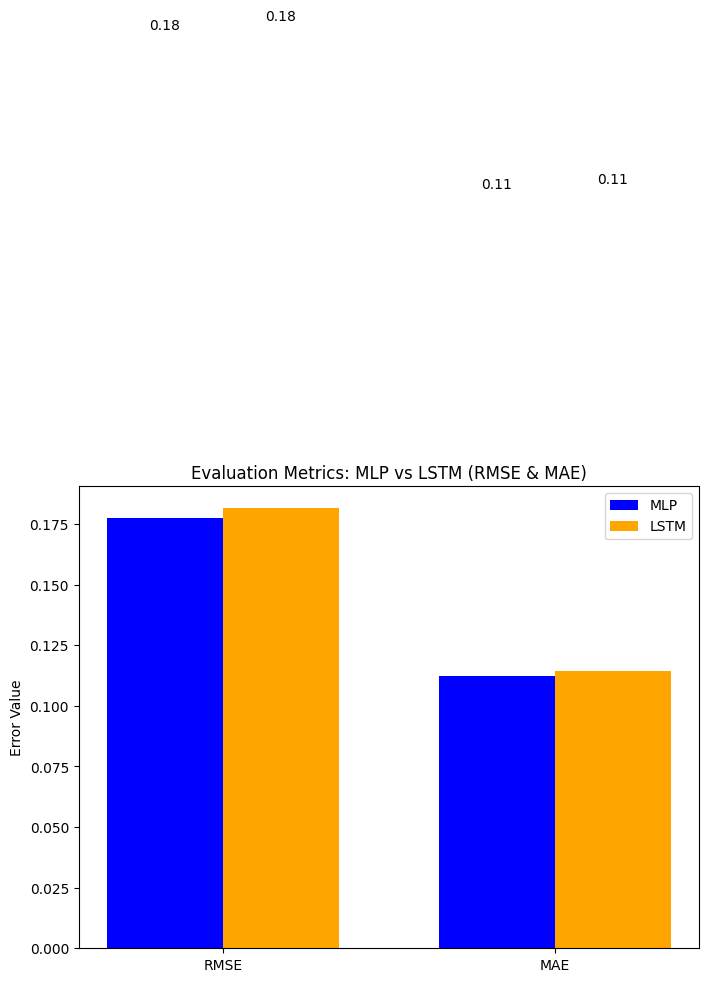

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


mlp_rmse = 0.177646544604944
lstm_rmse = 0.18149149392219652
mlp_mae = 0.1121405847696993
lstm_mae = 0.11424274243427829

# Metrics labels
metrics = ['RMSE', 'MAE']

# Values for MLP and LSTM models
mlp_values = [mlp_rmse, mlp_mae]
lstm_values = [lstm_rmse, lstm_mae]

# X-axis labels for MLP and LSTM comparison
x = np.arange(len(metrics))

# Width of the bars
width = 0.35

# Plotting the bar chart
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars for MLP and LSTM
bar1 = ax.bar(x - width/2, mlp_values, width, label='MLP', color='blue')
bar2 = ax.bar(x + width/2, lstm_values, width, label='LSTM', color='orange')

# Adding title and labels
ax.set_title('Evaluation Metrics: MLP vs LSTM (RMSE & MAE)')
ax.set_ylabel('Error Value')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Adding values on top of the bars
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.2, round(yval, 2), ha='center', va='bottom')

# Add labels for both MLP and LSTM bars
add_labels(bar1)
add_labels(bar2)

# Display the chart
plt.show()


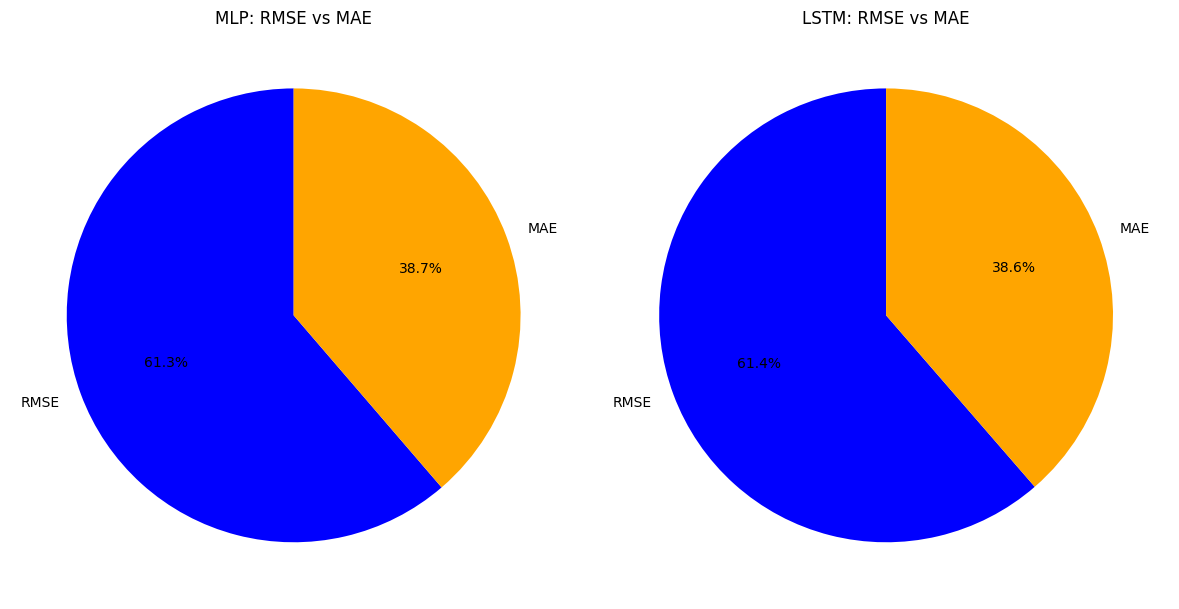

In [ ]:
import matplotlib.pyplot as plt


mlp_rmse = 0.177646544604944
lstm_rmse = 0.18149149392219652
mlp_mae = 0.1121405847696993
lstm_mae = 0.11424274243427829

# Data for pie chart
mlp_data = [mlp_rmse, mlp_mae]
lstm_data = [lstm_rmse, lstm_mae]

# Labels for the pie chart
labels = ['RMSE', 'MAE']

# Plotting MLP Pie chart
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # MLP pie chart
plt.pie(mlp_data, labels=labels, autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])
plt.title('MLP: RMSE vs MAE')

# Plotting LSTM Pie chart
plt.subplot(1, 2, 2)  # LSTM pie chart
plt.pie(lstm_data, labels=labels, autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])
plt.title('LSTM: RMSE vs MAE')

# Display the chart
plt.tight_layout()
plt.show()
